# CPWL operator timing against the SVD, tolerance-stopped
Timing against the SVD (exp4), re-run on the CPWL spectral operator of exp6 (the $\mathrm{clip}$ profile by default): every internal $\mathrm{Sgn}$ call inside the operator's sign form is run with `sign_map.make_sgn_ns_until` until it reaches a residual tolerance $\varepsilon$ instead of a fixed iteration count $K_D$. Both routes evaluate the same CPWL operator on the same matrix, against the exact operator read off a signed SVD (`cpwl_operator.spectral_reference`). Each of the `n_reps` repetitions uses a new random matrix of the same size and $\sigma_{\min}$, so the reported std is over matrices. Edit the config and rerun; set `devices=["cpu"]` without a GPU.

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so ns_core and experiments import

import matplotlib.pyplot as plt
import torch

from ns_core import plots
from experiments.cpwl_svd_timing import CPWLSvdTimingConfig, run_cpwl_svd_timing, cpwl_results_table
from experiments.svd_timing import time_table, speedup_table, smin_table  # same result layout as exp4
%matplotlib inline

In [ ]:
cfg = CPWLSvdTimingConfig(
    sizes=[64, 128, 256, 512], smins=[1e-2], degrees=[1, 2, 3, 4],
    devices=["cuda"], dtype=torch.float32,
    profile="clip",                        # which of the fields below are read depends on the profile
    alpha=-0.5, beta=0.5, gamma=0.3, a=0.2, mu=0.4, knots=None, vals=None,
    eps=1e-,     # residual target for every internal sign call
    k_max=50,     # step cap per sign call; one that misses eps is flagged
    power_iters=10, power_margin=1.1,
    time_unit="ms", time_round_digits=2,
    n_warmup=2, n_reps=10, cpu_threads=None, seed=0,
    verbose=True,  # progress only, results are in the tables below
)
res = run_cpwl_svd_timing(cfg)

[1/4] n=64 smin=0.01 (10 matrices)
[2/4] n=128 smin=0.01 (10 matrices)
[3/4] n=256 smin=0.01 (10 matrices)
[4/4] n=512 smin=0.01 (10 matrices)


## Time against size and against $\sigma_{\min}$

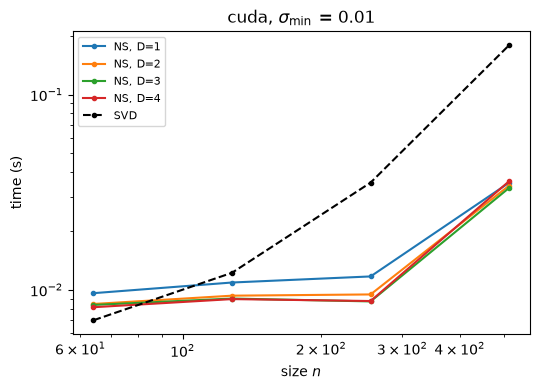

In [9]:
smin_plot = 1e-2  # sigma_min shown in the time-vs-size panel and the tables
n_plot = 128     # size shown in the time-vs-smin panel and tables
fig, axs = plt.subplots(1, len(res["cfg"].devices), figsize=(5.5 * len(res["cfg"].devices), 4), squeeze=False)
for ax, device in zip(axs[0], res["cfg"].devices):
    plots.plot_time_vs_size(res, device, smin_plot, ax=ax)
fig.tight_layout()

time (s), median ± std over 10 matrices: cuda, n = 128
smin  D=1              D=2               D=3                D=4               SVD             
0.01  0.0109 ± 0.0049  0.00932 ± 0.0038  0.00901 ± 0.00039  0.00895 ± 0.0004  0.0122 ± 0.00068



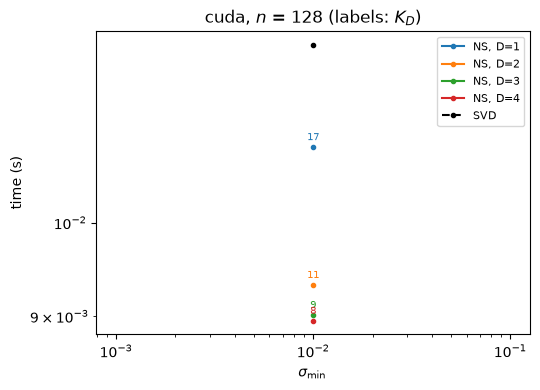

In [10]:
fig, axs = plt.subplots(1, len(res["cfg"].devices), figsize=(5.5 * len(res["cfg"].devices), 4), squeeze=False)
for ax, device in zip(axs[0], res["cfg"].devices):
    plots.plot_time_vs_smin(res, device, n_plot, ax=ax)
fig.tight_layout()
for device in res["cfg"].devices:
    smin_table(res, device, n_plot)
    print()

## Tables
Time and speedup over the SVD-based evaluation at `smin_plot`, then, for every $\sigma_{\min}$, the relative Frobenius error against the exact CPWL operator, evaluation time, number of internal sign-map calls, and the largest iteration count any of those calls needed to reach $\varepsilon$, one row per degree $D$.

In [11]:
for device in res["cfg"].devices:
    time_table(res, device, smin_plot)
    print()
    speedup_table(res, device, smin_plot)
    print()
    for smin in cfg.smins:
        cpwl_results_table(res, device, 128, smin)
        print()

time (s), median ± std over 10 matrices: cuda, smin = 0.01
n    D=1               D=2                D=3                D=4                SVD             
64   0.0096 ± 0.00038  0.00845 ± 0.00049  0.00836 ± 0.00067  0.00813 ± 0.0014   0.00697 ± 0.0019
128  0.0109 ± 0.0049   0.00932 ± 0.0038   0.00901 ± 0.00039  0.00895 ± 0.0004   0.0122 ± 0.00068
256  0.0117 ± 0.0032   0.00946 ± 0.00044  0.00871 ± 0.00025  0.00875 ± 0.00021  0.0354 ± 0.00035
512  0.0354 ± 0.00087  0.0342 ± 0.0016    0.0333 ± 0.0011    0.036 ± 0.0011     0.179 ± 0.0028  

speedup over the SVD (median times): cuda, smin = 0.01
n    D=1    D=2    D=3    D=4  
64   0.73x  0.83x  0.83x  0.86x
128  1.12x  1.31x  1.36x  1.36x
256  3.02x  3.74x  4.06x  4.04x
512  5.07x  5.24x  5.39x  4.97x

CPWL operator (clip), tolerance eps = 1e-06, mean/max over 10 matrices: cuda, n = 128, smin = 0.01
     rel. Frobenius error  time      # sign calls  max K
D=1  5.78e-07              10.89 ms  3.0           17   
D=2  5.74e-07             